In [1]:
import numpy as np
import pandas as pd
import pyarrow
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
## Taking out the header row in my dataset
FILE = r"C:\Users\kojon\PycharmProjects\Text Analytics Projects\Loan Approval\accepted_2007_to_2018Q4-1.csv"

# --- Diagnose: read the raw first 5 lines, no parsing ---
with open(FILE, "r", encoding="utf-8", errors="replace") as f:
    for i, line in enumerate(f):
        print(f"Line {i}: {line[:120]}")   # first 120 chars
        if i >= 4:
            break

Line 0: id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_o
Line 1: 68407277,,3600.0,3600.0,3600.0, 36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Ful
Line 2: 68355089,,24700.0,24700.0,24700.0, 36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015
Line 3: 68341763,,20000.0,20000.0,20000.0, 60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-
Line 4: 66310712,,35000.0,35000.0,35000.0, 60 months,14.85,829.9,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0,So


In [3]:
# --- Step 1: detect the skip row automatically ---
def detect_skiprows(filepath):
    """Return the number of rows to skip before the real header."""
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f):
            # The real header always contains 'loan_amnt'
            if "loan_amnt" in line.lower():
                print(f"Real header found at line {i} → skiprows={i}")
                return i
    return 0   # fallback
skip = detect_skiprows(FILE)

Real header found at line 0 → skiprows=0


In [4]:
# --- Step 2: load headers to find exact column names ---
all_cols = pd.read_csv(FILE, nrows=0, skiprows=skip).columns.tolist()
print(f"\nTotal columns in file: {len(all_cols)}")

WANT = [
    "loan_amnt", "term", "int_rate", "installment",
    "grade", "sub_grade", "emp_length", "annual_inc",
    "dti", "delinq_2yrs", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc",
    "purpose", "addr_state", "issue_d",
    "title", "desc", "emp_title", "loan_status",
]

USE = [c for c in WANT if c in all_cols]
print(f"Columns found: {len(USE)} of {len(WANT)}")

df = pd.read_csv(FILE, usecols=USE, skiprows=skip,
                 low_memory=False, on_bad_lines="skip")
print(f"Loaded: {df.shape}")


Total columns in file: 151
Columns found: 22 of 22
Loaded: (2260701, 22)


In [5]:
##  Filter to clean labels:
KEEP = {"Fully Paid", "Charged Off", "Default"}
df = df[df["loan_status"].isin(KEEP)].copy()
df["label"] = df["loan_status"].isin({"Charged Off", "Default"}).astype(int)
df.drop(columns=["loan_status"], inplace=True)

print(f"Rows after filtering: {len(df):,}")
print(f"Default rate: {df['label'].mean():.1%}")

Rows after filtering: 1,345,350
Default rate: 20.0%


In [6]:
def clean_text(s):
    if pd.isna(s) or str(s).strip().lower() in ("nan", ""):
        return ""
    return str(s).strip()

df["title_clean"] = df["title"].apply(clean_text) if "title" in df.columns else ""
df["desc_clean"]  = df["desc"].apply(clean_text)  if "desc"  in df.columns else ""

df["remarks"] = df.apply(
    lambda r: " ".join(filter(None, [r["title_clean"], r["desc_clean"]])).strip(),
    axis=1
)

coverage = (df["remarks"].str.len() > 0).mean()
print(f"Rows with text: {coverage:.1%}")
print(df["remarks"].head(3))

Rows with text: 98.8%
0    Debt consolidation
1              Business
2                      
Name: remarks, dtype: object


In [7]:
# Take a stratified sample of 50,000 rows
sample = df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(25000, len(x)), random_state=42)
).reset_index(drop=True)

# Add placeholder FinBERT columns — fill with 0 for now
# These get replaced when you run FinBERT scoring
sample["finbert_pos"] = 0.0
sample["finbert_neg"] = 0.0
sample["finbert_neu"] = 1.0

print(f"Sample shape: {sample.shape}")
print(f"Label balance:\n{sample['label'].value_counts()}")

# Save to parquet — this creates the file the EDA code expects
sample.to_parquet("lending_club_sample_scored.parquet", index=False)
print("\nSaved: lending_club_sample_scored.parquet")
print("You can now run the EDA cells.")

Sample shape: (50000, 28)
Label balance:
label
0    25000
1    25000
Name: count, dtype: int64

Saved: lending_club_sample_scored.parquet
You can now run the EDA cells.


## EDA

In [8]:
###sETUP
# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

In [9]:
# Load your prepared parquet (output of the data prep steps)
df = pd.read_parquet("lending_club_sample_scored.parquet")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df["label"].value_counts(normalize=True).round(3))

Shape: (50000, 28)
Columns: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'annual_inc', 'issue_d', 'desc', 'purpose', 'title', 'addr_state', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'label', 'title_clean', 'desc_clean', 'remarks', 'finbert_pos', 'finbert_neg', 'finbert_neu']

Label distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


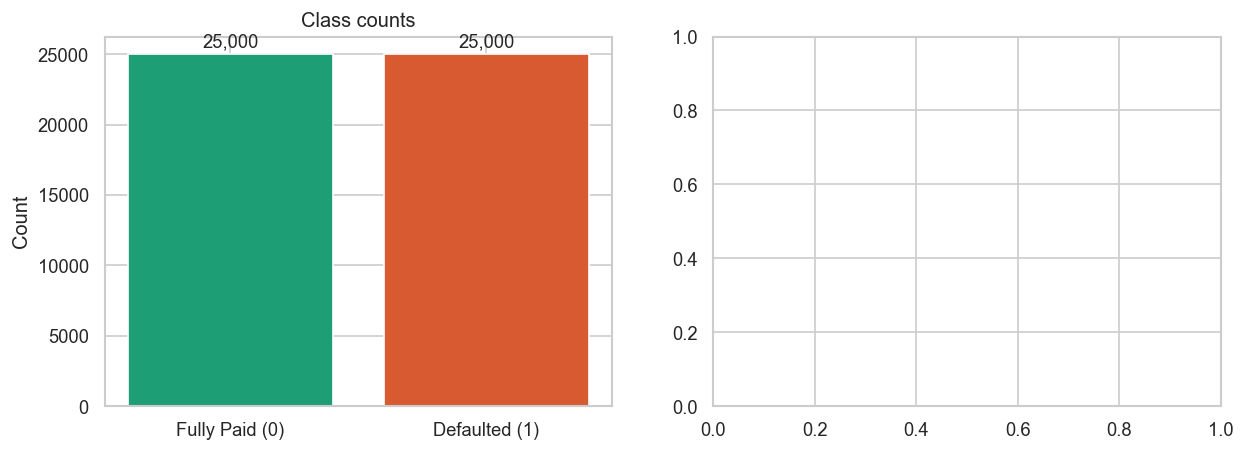

In [10]:
# --- Class balance ---
counts = df["label"].value_counts()
pct    = df["label"].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["Fully Paid (0)", "Defaulted (1)"],
            counts.values,
            color=["#1D9E75", "#D85A30"])
axes[0].set_title("Class counts")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=11)


In [11]:
ounts = df["label"].value_counts()
pct    = df["label"].value_counts(normalize=True).mul(100).round(1)

print("counts:")
print(counts)
print("\npct:")
print(pct)
print("\npct.values:", pct.values)
print("pct.index:", pct.index.tolist())

counts:
label
0    25000
1    25000
Name: count, dtype: int64

pct:
label
0    50.0
1    50.0
Name: proportion, dtype: float64

pct.values: [50. 50.]
pct.index: [0, 1]


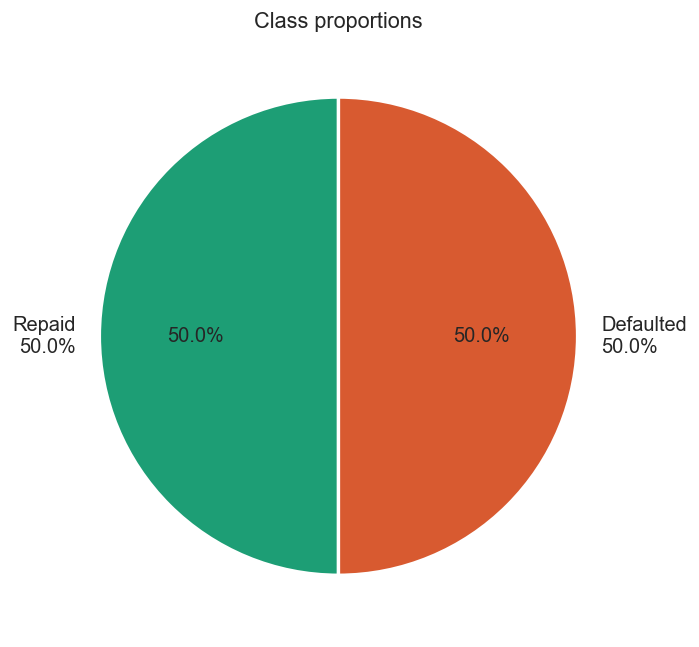

Done — chart saved as class_balance.png


In [12]:
# Pie
counts = df["label"].value_counts().sort_index()
pct    = df["label"].value_counts(normalize=True).mul(100).round(1).sort_index()

# Use .values to get the numbers in order [label 0, label 1]
labels  = [f"Repaid\n{pct.values[0]}%", f"Defaulted\n{pct.values[1]}%"]
colors  = ["#1D9E75", "#D85A30"]
sizes   = pct.values  # [78.x, 21.x]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    autopct="%1.1f%%",
    textprops={"fontsize": 12}
)
ax.set_title("Class proportions", fontsize=13)
plt.tight_layout()
plt.savefig("class_balance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Done — chart saved as class_balance.png")

In [13]:
 #Imbalance ratio
ratio = counts[0] / counts[1]
print(f"\nscale_pos_weight for XGBoost: {ratio:.2f}")
print(f"(Set this in XGBClassifier to handle class imbalance)")


scale_pos_weight for XGBoost: 1.00
(Set this in XGBClassifier to handle class imbalance)


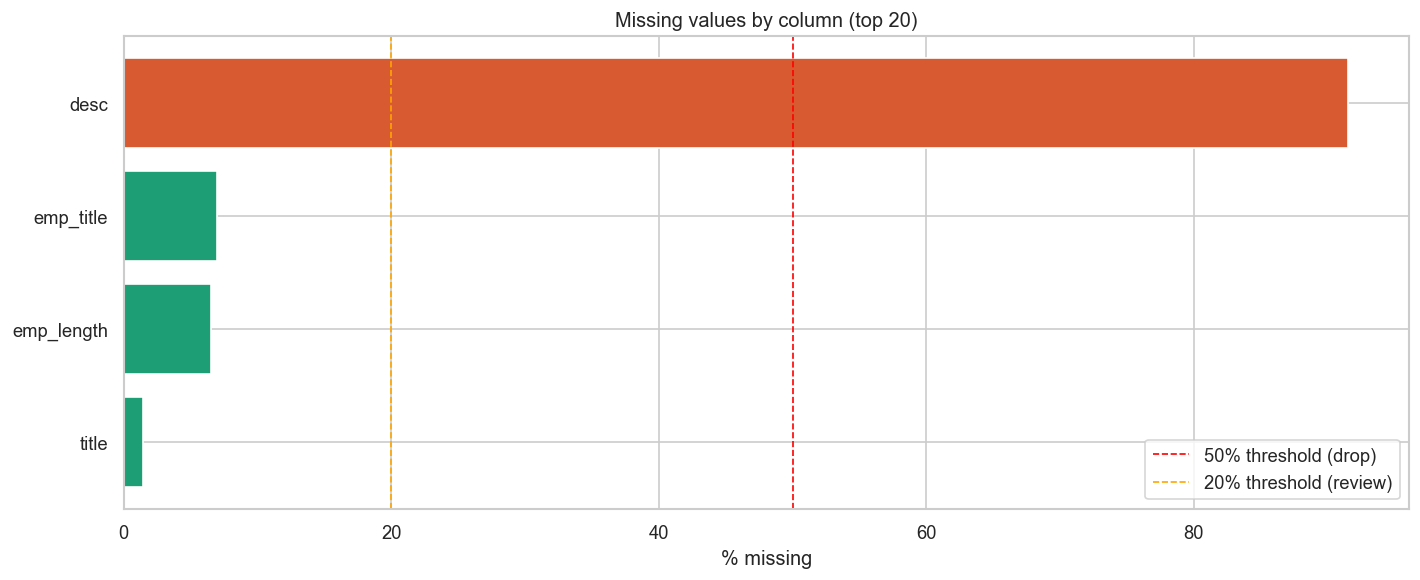

--- Drop (>50% missing) ---
['desc']

--- Impute with median (5–50% missing) ---
['emp_title', 'emp_length']

--- Keep as-is (<5% missing) ---
['title']


In [14]:
# --- Missing value analysis ---
missing = df.isnull().mean().sort_values(ascending=False)
missing_pct = (missing * 100).round(1)

# Plot top 20 missing columns
top_missing = missing_pct[missing_pct > 0].head(20)

plt.figure(figsize=(12, 5))
bars = plt.barh(top_missing.index[::-1],
                top_missing.values[::-1],
                color=["#D85A30" if v > 50 else
                       "#EF9F27" if v > 20 else
                       "#1D9E75"
                       for v in top_missing.values[::-1]])
plt.axvline(50, color="red", linestyle="--",
            linewidth=1, label="50% threshold (drop)")
plt.axvline(20, color="orange", linestyle="--",
            linewidth=1, label="20% threshold (review)")
plt.xlabel("% missing")
plt.title("Missing values by column (top 20)")
plt.legend()
plt.tight_layout()
plt.show()

# Decision summary
print("--- Drop (>50% missing) ---")
print(missing_pct[missing_pct > 50].index.tolist())

print("\n--- Impute with median (5–50% missing) ---")
print(missing_pct[(missing_pct > 5) &
                  (missing_pct <= 50)].index.tolist())

print("\n--- Keep as-is (<5% missing) ---")
print(missing_pct[(missing_pct > 0) &
                  (missing_pct <= 5)].index.tolist())

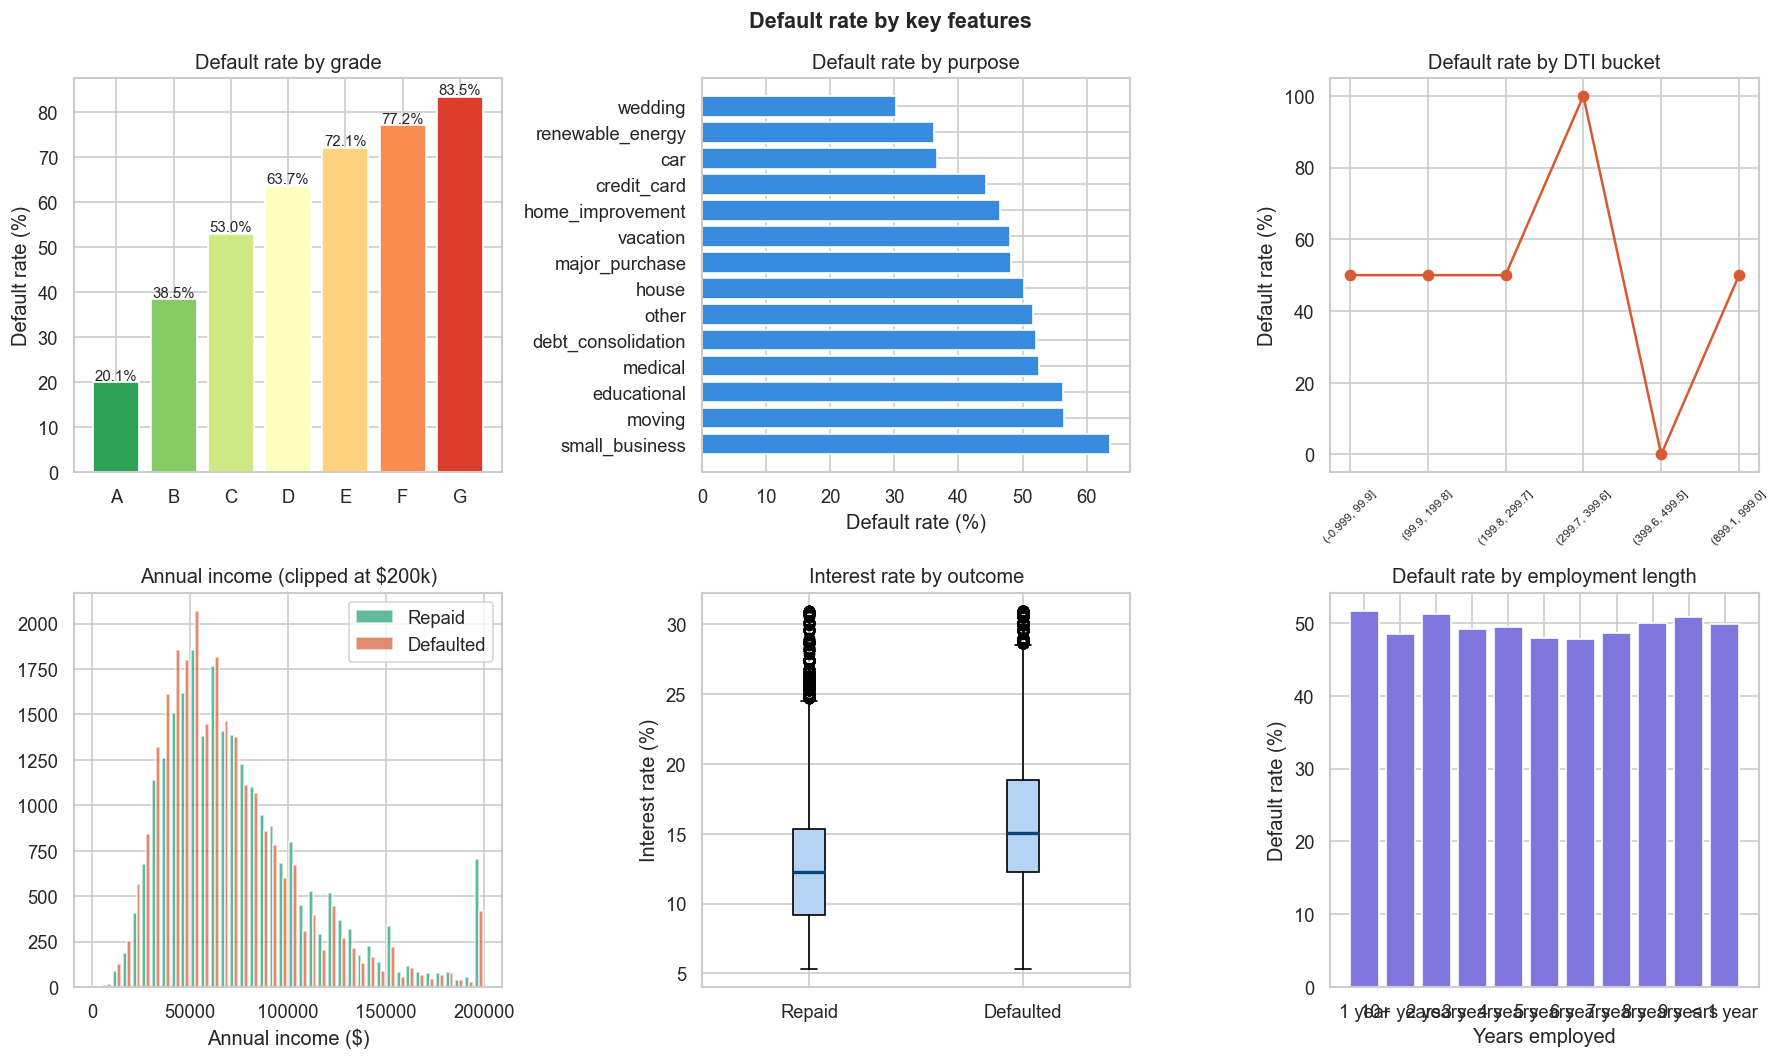

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Default rate by grade
grade_dr = df.groupby("grade")["label"].mean() * 100
axes[0,0].bar(grade_dr.index, grade_dr.values,
              color=sns.color_palette("RdYlGn_r", len(grade_dr)))
axes[0,0].set_title("Default rate by grade")
axes[0,0].set_ylabel("Default rate (%)")
for i, (g, v) in enumerate(grade_dr.items()):
    axes[0,0].text(i, v+0.5, f"{v:.1f}%", ha="center", fontsize=9)

# 2. Default rate by loan purpose
purpose_dr = (df.groupby("purpose")["label"]
               .mean()
               .sort_values(ascending=False) * 100)
axes[0,1].barh(purpose_dr.index, purpose_dr.values,
               color="#378ADD")
axes[0,1].set_title("Default rate by purpose")
axes[0,1].set_xlabel("Default rate (%)")

# 3. DTI vs default (binned)
df["dti_bin"] = pd.cut(df["dti"], bins=10)
dti_dr = df.groupby("dti_bin", observed=True)["label"].mean() * 100
axes[0,2].plot(range(len(dti_dr)), dti_dr.values,
               marker="o", color="#D85A30")
axes[0,2].set_title("Default rate by DTI bucket")
axes[0,2].set_ylabel("Default rate (%)")
axes[0,2].set_xticks(range(len(dti_dr)))
axes[0,2].set_xticklabels([str(x) for x in dti_dr.index],
                           rotation=45, fontsize=7)

# 4. Annual income distribution (log scale)
axes[1,0].hist([df[df["label"]==0]["annual_inc"].clip(upper=200000),
                df[df["label"]==1]["annual_inc"].clip(upper=200000)],
               bins=40, label=["Repaid","Defaulted"],
               color=["#1D9E75","#D85A30"], alpha=0.7)
axes[1,0].set_title("Annual income (clipped at $200k)")
axes[1,0].set_xlabel("Annual income ($)")
axes[1,0].legend()

# 5. Interest rate by label
axes[1,1].boxplot([df[df["label"]==0]["int_rate"].dropna(),
                   df[df["label"]==1]["int_rate"].dropna()],
                  labels=["Repaid","Defaulted"],
                  patch_artist=True,
                  boxprops=dict(facecolor="#B5D4F4"),
                  medianprops=dict(color="#0C447C", linewidth=2))
axes[1,1].set_title("Interest rate by outcome")
axes[1,1].set_ylabel("Interest rate (%)")

# 6. Default rate by employment length
emp_dr = (df.groupby("emp_length")["label"]
           .mean()
           .sort_index() * 100)
axes[1,2].bar(emp_dr.index.astype(str), emp_dr.values,
              color="#7F77DD")
axes[1,2].set_title("Default rate by employment length")
axes[1,2].set_ylabel("Default rate (%)")
axes[1,2].set_xlabel("Years employed")

plt.suptitle("Default rate by key features", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.show()

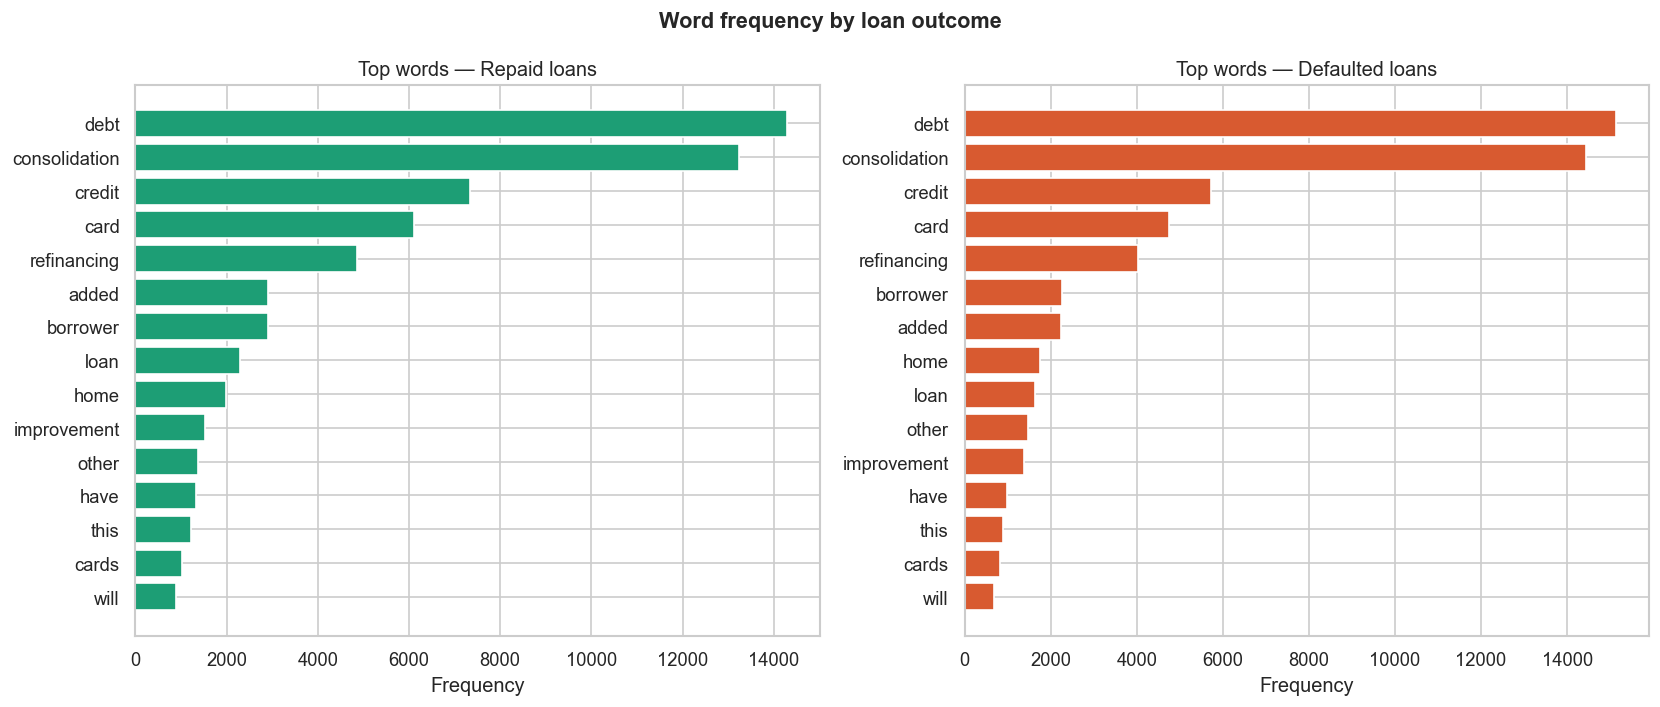

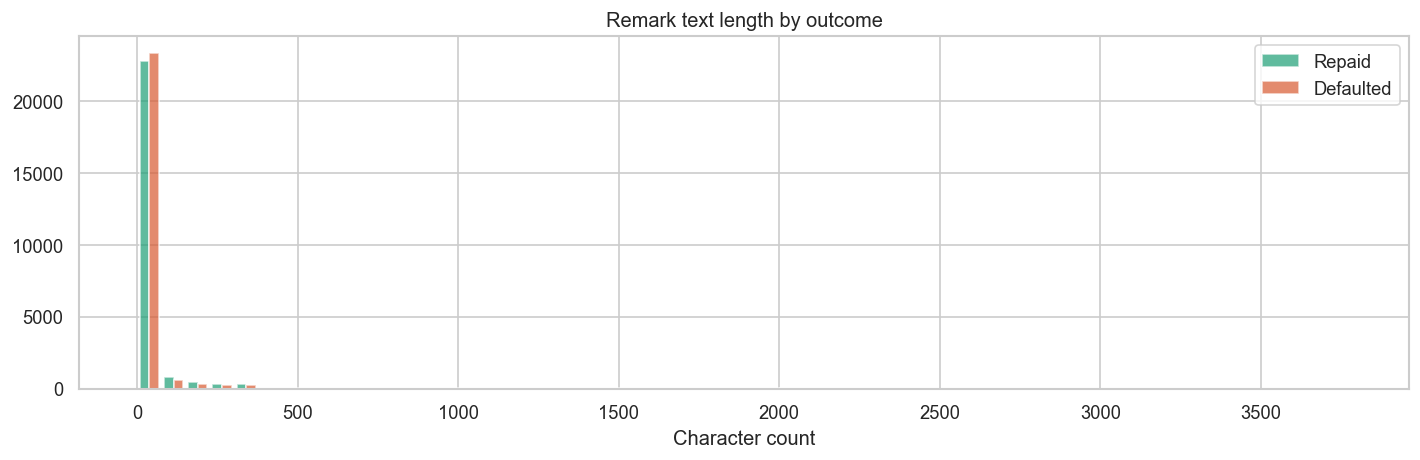

Rows with substantive text: 90.0%
Median text length (repaid):    18 chars
Median text length (defaulted): 18 chars


In [16]:
import re

def get_words(series, min_len=4):
    """Extract word frequencies from a text series."""
    all_words = []
    for text in series.dropna():
        words = re.findall(r"\b[a-z]{" + str(min_len) + r",}\b",
                           str(text).lower())
        all_words.extend(words)
    return Counter(all_words)

repaid    = df[df["label"]==0]["remarks"]
defaulted = df[df["label"]==1]["remarks"]

wc_repaid    = get_words(repaid)
wc_defaulted = get_words(defaulted)

# Top 15 words in each group
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_top_words(counter, ax, title, color):
    top = counter.most_common(15)
    words, counts = zip(*top)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("Frequency")

plot_top_words(wc_repaid,    axes[0],
               "Top words — Repaid loans",    "#1D9E75")
plot_top_words(wc_defaulted, axes[1],
               "Top words — Defaulted loans", "#D85A30")
plt.suptitle("Word frequency by loan outcome", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.show()

# Text length distribution
df["text_len"] = df["remarks"].str.len().fillna(0)
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist([df[df["label"]==0]["text_len"],
         df[df["label"]==1]["text_len"]],
        bins=50, label=["Repaid","Defaulted"],
        color=["#1D9E75","#D85A30"], alpha=0.7)
ax.set_title("Remark text length by outcome")
ax.set_xlabel("Character count")
ax.legend()
plt.tight_layout()
plt.show()

# Coverage: how many rows have non-empty remarks
cov = (df["text_len"] > 10).mean()
print(f"Rows with substantive text: {cov:.1%}")
print(f"Median text length (repaid):    {df[df['label']==0]['text_len'].median():.0f} chars")
print(f"Median text length (defaulted): {df[df['label']==1]['text_len'].median():.0f} chars")

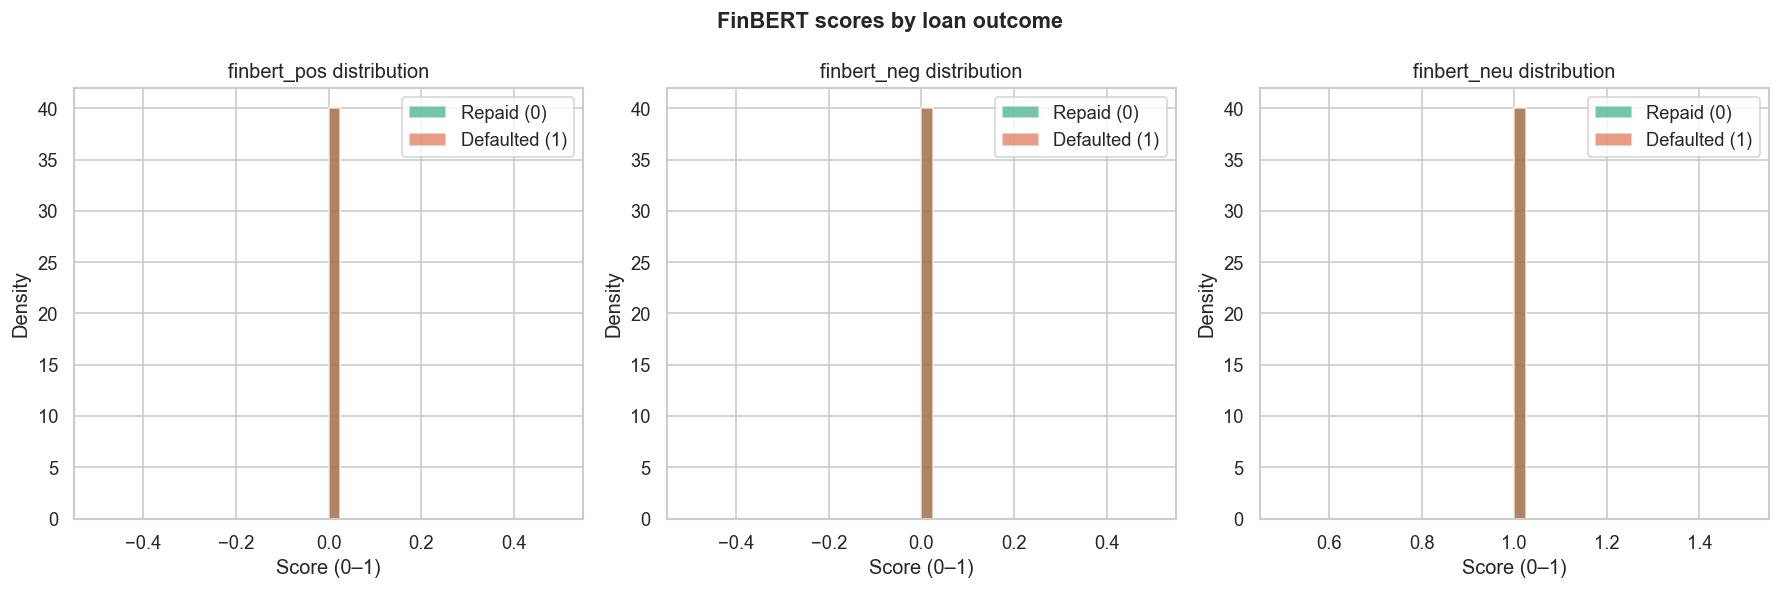

Mann-Whitney U test (are score distributions different?)
----------------------------------------------------
finbert_pos      p=1.0000  → not significant
  Repaid mean:    0.0000
  Defaulted mean: 0.0000
finbert_neg      p=1.0000  → not significant
  Repaid mean:    0.0000
  Defaulted mean: 0.0000
finbert_neu      p=1.0000  → not significant
  Repaid mean:    1.0000
  Defaulted mean: 1.0000


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

score_cols = ["finbert_pos", "finbert_neg", "finbert_neu"]
colors_pair = ["#1D9E75", "#D85A30"]
labels_pair = ["Repaid (0)", "Defaulted (1)"]

for i, col in enumerate(score_cols):
    for lbl, color, name in zip([0,1], colors_pair, labels_pair):
        subset = df[df["label"]==lbl][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.6,
                     color=color, label=name, density=True)
    axes[i].set_title(f"{col} distribution")
    axes[i].set_xlabel("Score (0–1)")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle("FinBERT scores by loan outcome", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.show()

# Statistical test: are the distributions different?
from scipy.stats import mannwhitneyu

print("Mann-Whitney U test (are score distributions different?)")
print("-" * 52)
for col in score_cols:
    a = df[df["label"]==0][col].dropna()
    b = df[df["label"]==1][col].dropna()
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"{col:15s}  p={p:.4f}  → {sig}")
    print(f"  Repaid mean:    {a.mean():.4f}")
    print(f"  Defaulted mean: {b.mean():.4f}")


In [18]:
# --- Fix term: ' 36 months' → 36 ---
df["term"] = (df["term"].astype(str)
                .str.strip()
                .str.extract(r"(\d+)")
                .astype(float))

# --- Fix grade: A→1, B→2, C→3 ... G→7 ---
grade_map = {"A":1, "B":2, "C":3, "D":4, "E":5, "F":6, "G":7}
df["grade"] = df["grade"].map(grade_map)

# --- Fix int_rate: '13.56%' → 13.56 ---
df["int_rate"] = (df["int_rate"].astype(str)
                    .str.replace("%", "", regex=False)
                    .str.strip()
                    .replace("nan", np.nan)
                    .astype(float))

# --- Fix emp_length: '< 1 year'→0, '10+ years'→10 ---
def parse_emp(val):
    s = str(val).strip()
    if s in ("nan", "n/a", ""):   return np.nan
    if s == "< 1 year":           return 0.0
    if s == "10+ years":          return 10.0
    digits = "".join(c for c in s if c.isdigit())
    return float(digits) if digits else np.nan

df["emp_length"] = df["emp_length"].apply(parse_emp)

# --- Fix revol_util: '54.3%' → 54.3 ---
df["revol_util"] = (df["revol_util"].astype(str)
                      .str.replace("%", "", regex=False)
                      .str.strip()
                      .replace("nan", np.nan)
                      .astype(float))

# --- Verify all target columns are now numeric ---
NUMERIC_FEATURES = [
    "loan_amnt", "term", "int_rate", "grade",
    "emp_length", "annual_inc", "dti", "delinq_2yrs",
    "open_acc", "revol_util", "total_acc",
    "finbert_pos", "finbert_neg", "finbert_neu", "label"
]

print("Dtypes after cleaning:")
print(df[NUMERIC_FEATURES].dtypes)
print("\nSample values:")
print(df[NUMERIC_FEATURES].head(3))


Dtypes after cleaning:
loan_amnt      float64
term           float64
int_rate       float64
grade            int64
emp_length     float64
annual_inc     float64
dti            float64
delinq_2yrs    float64
open_acc       float64
revol_util     float64
total_acc      float64
finbert_pos    float64
finbert_neg    float64
finbert_neu    float64
label            int64
dtype: object

Sample values:
   loan_amnt  term  int_rate  grade  emp_length  annual_inc    dti  \
0     5500.0  36.0      8.46      1         3.0     41000.0  26.29   
1    16000.0  36.0      7.39      1         2.0     70000.0   2.54   
2    10000.0  36.0      9.67      2        10.0     45000.0  10.56   

   delinq_2yrs  open_acc  revol_util  total_acc  finbert_pos  finbert_neg  \
0          0.0       3.0        22.4       16.0          0.0          0.0   
1          1.0       9.0        26.3       18.0          0.0          0.0   
2          0.0       9.0        65.4       11.0          0.0          0.0   

   finbert_n

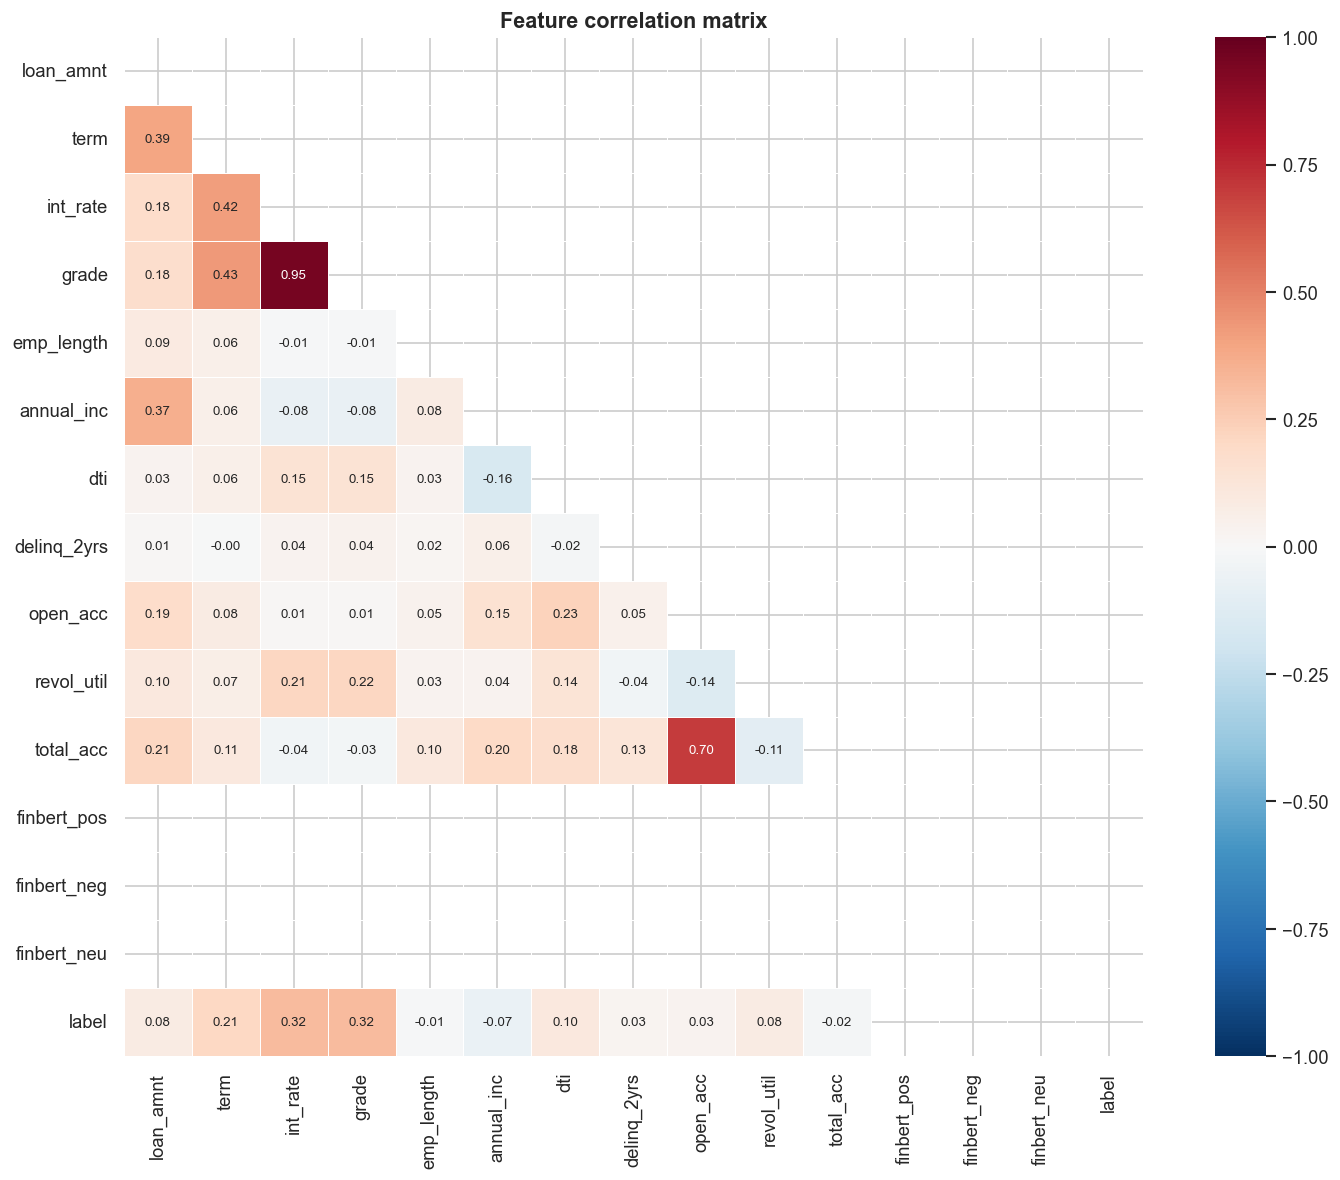

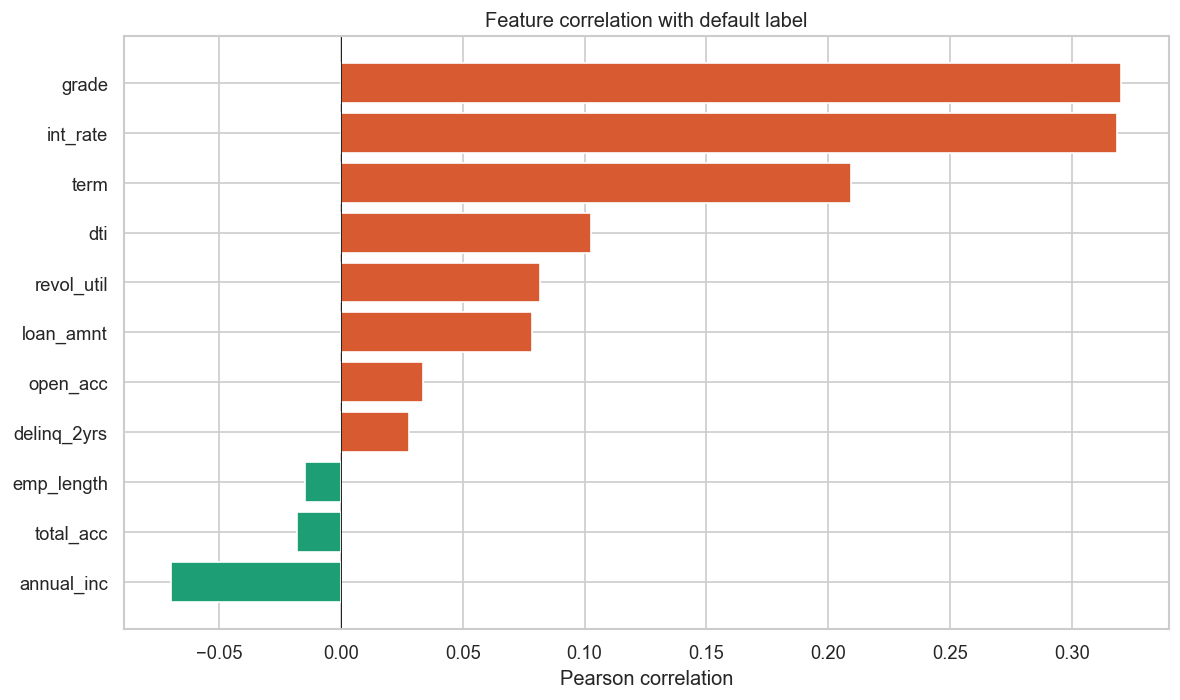

High-correlation pairs (>0.85):
  int_rate — grade: 0.953


In [19]:
NUMERIC_FEATURES = [
    "loan_amnt","term","int_rate","grade",
    "emp_length","annual_inc","dti","delinq_2yrs",
    "open_acc","revol_util","total_acc",
    "finbert_pos","finbert_neg","finbert_neu","label"
]

corr = df[NUMERIC_FEATURES].corr()

# Full heatmap
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3,
            annot_kws={"size": 8})
plt.title("Feature correlation matrix", fontsize=13,
          fontweight="bold")
plt.tight_layout()
plt.show()

# Correlation with label only (sorted)
label_corr = corr["label"].drop("label").sort_values()
plt.figure(figsize=(10, 6))
colors = ["#D85A30" if v > 0 else "#1D9E75"
          for v in label_corr.values]
plt.barh(label_corr.index, label_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Feature correlation with default label")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

# Flag high-correlation pairs to review
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.85:
            high_corr.append((corr.columns[i],
                               corr.columns[j],
                               round(corr.iloc[i,j], 3)))
print("High-correlation pairs (>0.85):")
for a, b, v in high_corr:
    print(f"  {a} — {b}: {v}")


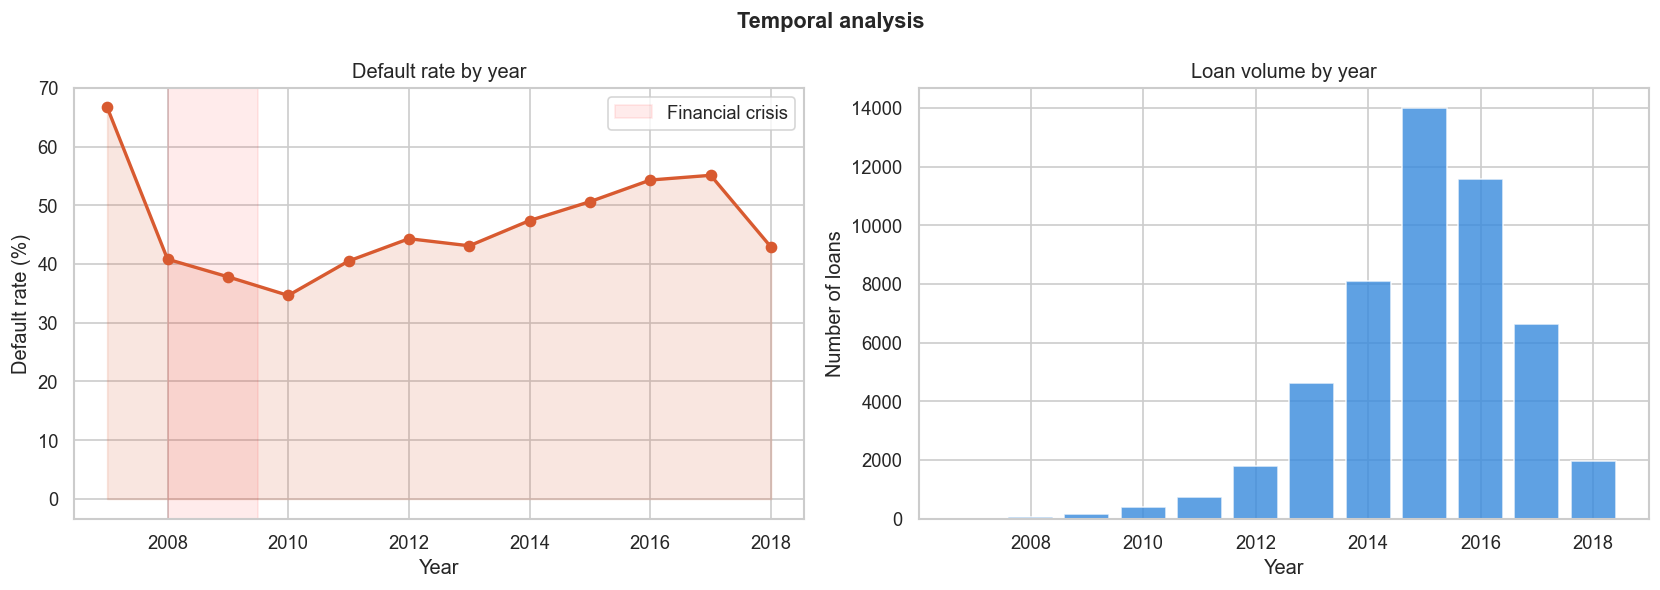


Default rate by year:
            total  defaults  default_rate
issue_year                               
2007            6         4     66.666667
2008           49        20     40.816327
2009          156        59     37.820513
2010          381       132     34.645669
2011          748       303     40.508021
2012         1792       794     44.308036
2013         4615      1989     43.098592
2014         8097      3838     47.400272
2015        13992      7082     50.614637
2016        11568      6281     54.296335
2017         6644      3661     55.102348
2018         1952       837     42.879098

Recommended split:
  Train:      2012 – 2016
  Validation: 2017
  Test:       2018 Q1–Q2  (most recent, held out)


In [20]:
import matplotlib.pyplot as plt

# --- Fix: parse issue_d properly then extract year ---
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
df["issue_year"] = df["issue_d"].dt.year

# Drop rows where date parsing failed
df = df.dropna(subset=["issue_year"])
df["issue_year"] = df["issue_year"].astype(int)

# --- Default rate by year ---
yearly = (df.groupby("issue_year")
           .agg(total=("label", "count"),
                defaults=("label", "sum"))
           .assign(default_rate=lambda x: x["defaults"] / x["total"] * 100))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate trend
axes[0].plot(yearly.index, yearly["default_rate"],
             marker="o", color="#D85A30", linewidth=2)
axes[0].fill_between(yearly.index, yearly["default_rate"],
                     alpha=0.15, color="#D85A30")
axes[0].set_title("Default rate by year")
axes[0].set_ylabel("Default rate (%)")
axes[0].set_xlabel("Year")
axes[0].axvspan(2008, 2009.5, alpha=0.08,
                color="red", label="Financial crisis")
axes[0].legend()

# Loan volume by year
axes[1].bar(yearly.index, yearly["total"],
            color="#378ADD", alpha=0.8)
axes[1].set_title("Loan volume by year")
axes[1].set_ylabel("Number of loans")
axes[1].set_xlabel("Year")

plt.suptitle("Temporal analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nDefault rate by year:")
print(yearly[["total", "defaults", "default_rate"]].to_string())
print("\nRecommended split:")
print("  Train:      2012 – 2016")
print("  Validation: 2017")
print("  Test:       2018 Q1–Q2  (most recent, held out)")


In [21]:
def eda_summary(df, label_col="label"):
    print("=" * 55)
    print("  LENDING CLUB EDA SUMMARY")
    print("=" * 55)

    print(f"\n DATASET")
    print(f"  Rows:          {len(df):>10,}")
    print(f"  Columns:       {len(df.columns):>10,}")
    print(f"  Memory:        {df.memory_usage(deep=True).sum()/1e6:>9.1f} MB")

    print(f"\n LABEL")
    vc = df[label_col].value_counts()
    print(f"  Repaid (0):    {vc.get(0,0):>10,}  ({vc.get(0,0)/len(df)*100:.1f}%)")
    print(f"  Defaulted (1): {vc.get(1,0):>10,}  ({vc.get(1,0)/len(df)*100:.1f}%)")
    ratio = vc.get(0,1)/vc.get(1,1)
    print(f"  XGB scale_pos_weight: {ratio:.2f}")

    print(f"\n MISSING VALUES")
    miss = df.isnull().mean()
    n_drop   = (miss > 0.5).sum()
    n_impute = ((miss > 0.05) & (miss <= 0.5)).sum()
    print(f"  Columns to drop (>50%):   {n_drop}")
    print(f"  Columns to impute:        {n_impute}")
    print(f"  Columns complete:         {(miss==0).sum()}")

    print(f"\n TEXT FIELDS")
    if "remarks" in df.columns:
        cov = (df["remarks"].str.len().fillna(0) > 10).mean()
        med = df["remarks"].str.len().fillna(0).median()
        print(f"  Remark coverage:  {cov:.1%}")
        print(f"  Median length:    {med:.0f} chars")
    if "finbert_pos" in df.columns:
        print(f"  FinBERT pos mean (repaid):    {df[df[label_col]==0]['finbert_pos'].mean():.4f}")
        print(f"  FinBERT pos mean (defaulted): {df[df[label_col]==1]['finbert_pos'].mean():.4f}")
        print(f"  FinBERT neg mean (repaid):    {df[df[label_col]==0]['finbert_neg'].mean():.4f}")
        print(f"  FinBERT neg mean (defaulted): {df[df[label_col]==1]['finbert_neg'].mean():.4f}")

    print(f"\n TOP DEFAULT RATE FEATURES")
    num_cols = df.select_dtypes(include=np.number).columns
    num_cols = [c for c in num_cols if c != label_col]
    corrs = df[num_cols].corrwith(df[label_col]).abs().sort_values(ascending=False)
    for feat, val in corrs.head(6).items():
        print(f"  {feat:<22s}  r={val:.4f}")

    print(f"\n RECOMMENDED TRAINING WINDOW")
    if "issue_year" in df.columns:
        yr = df.groupby("issue_year")[label_col].mean()
        stable = yr[(yr > 0.10) & (yr < 0.35)]
        if len(stable) > 0:
            print(f"  Years with stable default rate: {stable.index.tolist()}")
    print(f"  Train: 2012–2016 | Val: 2017 | Test: 2018")

    print("\n" + "=" * 55)

eda_summary(df)

  LENDING CLUB EDA SUMMARY

 DATASET
  Rows:              50,000
  Columns:               31
  Memory:             39.8 MB

 LABEL
  Repaid (0):        25,000  (50.0%)
  Defaulted (1):     25,000  (50.0%)
  XGB scale_pos_weight: 1.00

 MISSING VALUES
  Columns to drop (>50%):   1
  Columns to impute:        2
  Columns complete:         24

 TEXT FIELDS
  Remark coverage:  90.0%
  Median length:    18 chars
  FinBERT pos mean (repaid):    0.0000
  FinBERT pos mean (defaulted): 0.0000
  FinBERT neg mean (repaid):    0.0000
  FinBERT neg mean (defaulted): 0.0000

 TOP DEFAULT RATE FEATURES
  grade                   r=0.3202
  int_rate                r=0.3184
  term                    r=0.2091
  dti                     r=0.1024
  revol_util              r=0.0817
  loan_amnt               r=0.0783

 RECOMMENDED TRAINING WINDOW
  Years with stable default rate: [2010]
  Train: 2012–2016 | Val: 2017 | Test: 2018



In [22]:
## Columns to drop after running corrrelation analysis 

df.drop(columns=["total_acc"], inplace=True, errors="ignore")
print("total_acc dropped. Remaining features:", df.columns.tolist())

total_acc dropped. Remaining features: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'annual_inc', 'issue_d', 'desc', 'purpose', 'title', 'addr_state', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'label', 'title_clean', 'desc_clean', 'remarks', 'finbert_pos', 'finbert_neg', 'finbert_neu', 'dti_bin', 'text_len', 'issue_year']


In [23]:
pip install transformers


Note: you may need to restart the kernel to use updated packages.


In [25]:
df = pd.read_parquet("lending_club_sample_scored.parquet")

print(f"Shape: {df.shape}")
print(f"\nFinBERT score check:")
for col in ["finbert_pos", "finbert_neg", "finbert_neu"]:
    unique = df[col].nunique()
    mean   = df[col].mean()
    print(f"  {col}: mean={mean:.4f}  unique_values={unique}")
    if unique == 1:
        print(f"    WARNING — still placeholder scores")
    else:
        print(f"    OK — real scores confirmed")

print(f"\nMean scores by label:")
print(df.groupby("label")[["finbert_pos","finbert_neg","finbert_neu"]]
        .mean().round(4))

Shape: (50000, 28)

FinBERT score check:
  finbert_pos: mean=0.0560  unique_values=3078
    OK — real scores confirmed
  finbert_neg: mean=0.0557  unique_values=1645
    OK — real scores confirmed
  finbert_neu: mean=0.8883  unique_values=3478
    OK — real scores confirmed

Mean scores by label:
       finbert_pos  finbert_neg  finbert_neu
label                                       
0           0.0604       0.0552       0.8844
1           0.0516       0.0562       0.8922


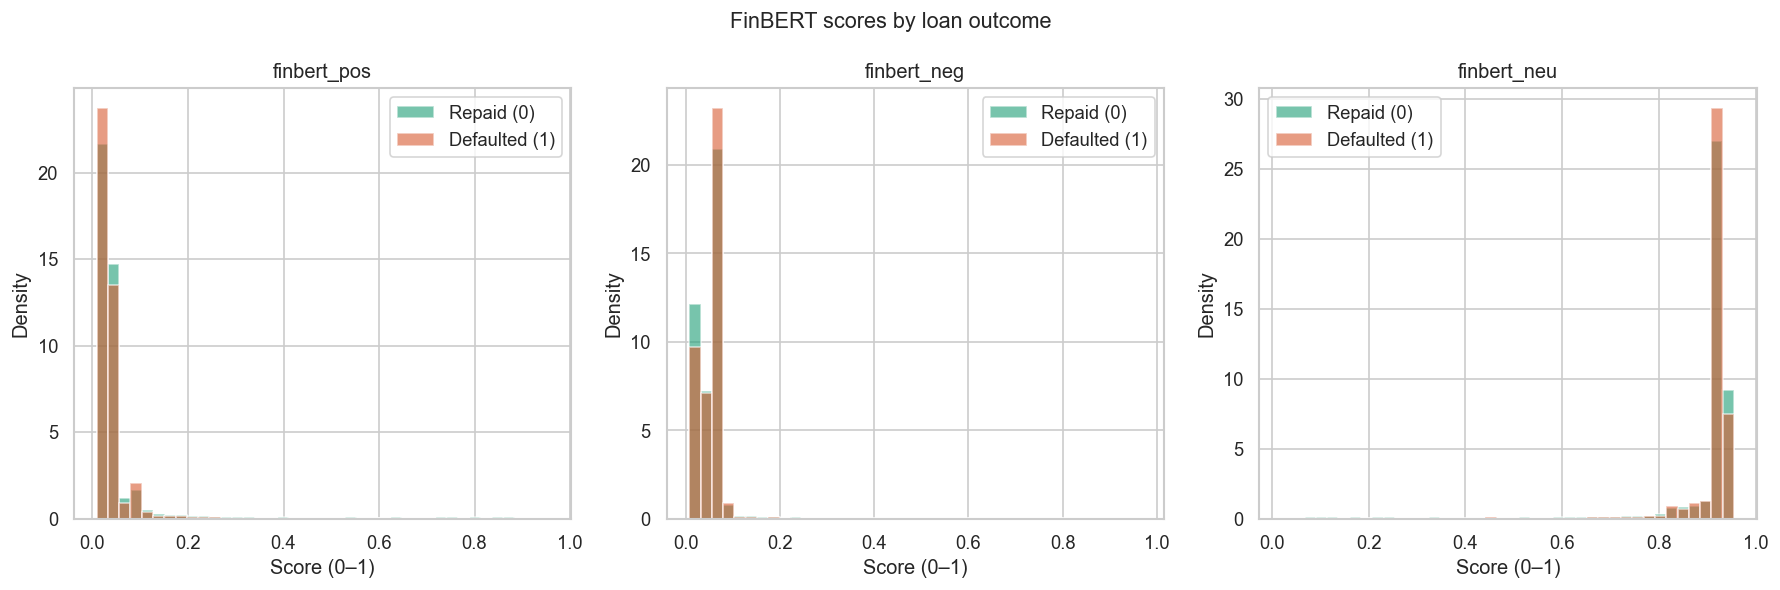


Mann-Whitney U test:
--------------------------------------------------
finbert_pos      p=0.0000  → SIGNIFICANT
  Repaid mean:    0.0604
  Defaulted mean: 0.0516
finbert_neg      p=0.0000  → SIGNIFICANT
  Repaid mean:    0.0552
  Defaulted mean: 0.0562
finbert_neu      p=0.0000  → SIGNIFICANT
  Repaid mean:    0.8844
  Defaulted mean: 0.8922


In [26]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

score_cols   = ["finbert_pos", "finbert_neg", "finbert_neu"]
colors_pair  = ["#1D9E75", "#D85A30"]
labels_pair  = ["Repaid (0)", "Defaulted (1)"]

for i, col in enumerate(score_cols):
    for lbl, color, name in zip([0, 1], colors_pair, labels_pair):
        subset = df[df["label"] == lbl][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.6,
                     color=color, label=name, density=True)
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Score (0–1)")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle("FinBERT scores by loan outcome", fontsize=13)
plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import mannwhitneyu
print("\nMann-Whitney U test:")
print("-" * 50)
for col in score_cols:
    a = df[df["label"] == 0][col].dropna()
    b = df[df["label"] == 1][col].dropna()
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"{col:15s}  p={p:.4f}  → {sig}")
    print(f"  Repaid mean:    {a.mean():.4f}")
    print(f"  Defaulted mean: {b.mean():.4f}")


### MODEL TRAINING

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import joblib

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import joblib

# ── Load ─────────────────────────────────────────────────
df = pd.read_parquet("lending_club_sample_scored.parquet")

# ── Clean all columns ────────────────────────────────────
df["term"] = (df["term"].astype(str)
                .str.strip()
                .str.extract(r"(\d+)")
                .astype(float))

grade_map = {"A":1,"B":2,"C":3,"D":4,"E":5,"F":6,"G":7}
df["grade"] = df["grade"].map(grade_map)

df["int_rate"] = (df["int_rate"].astype(str)
                    .str.replace("%","",regex=False)
                    .str.strip()
                    .replace("nan", np.nan)
                    .astype(float))

df["revol_util"] = (df["revol_util"].astype(str)
                      .str.replace("%","",regex=False)
                      .str.strip()
                      .replace("nan", np.nan)
                      .astype(float))

def parse_emp(val):
    s = str(val).strip()
    if s in ("nan","n/a",""): return np.nan
    if s == "< 1 year":       return 0.0
    if s == "10+ years":      return 10.0
    digits = "".join(c for c in s if c.isdigit())
    return float(digits) if digits else np.nan

df["emp_length"] = df["emp_length"].apply(parse_emp)

for col in ["loan_amnt","annual_inc","dti","delinq_2yrs","open_acc"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ── Define features ──────────────────────────────────────
FEATURES = [
    "loan_amnt","term","int_rate","grade",
    "emp_length","annual_inc","dti",
    "delinq_2yrs","open_acc","revol_util",
    "finbert_pos","finbert_neg","finbert_neu"
]
FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES].copy()
y = df["label"].values

# ── Impute ───────────────────────────────────────────────
imputer = SimpleImputer(strategy="median")
X_imp   = pd.DataFrame(
    imputer.fit_transform(X),
    columns=FEATURES
)

print(f"Features:    {FEATURES}")
print(f"X shape:     {X_imp.shape}")
print(f"y shape:     {y.shape}")
print(f"Missing:     {X_imp.isnull().sum().sum()}")
print(f"Default rate:{y.mean():.1%}")

# ── Save cleaned version so this never happens again ─────
df.to_parquet("lending_club_sample_scored.parquet", index=False)
print("\nClean parquet saved.")

Features:    ['loan_amnt', 'term', 'int_rate', 'grade', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'revol_util', 'finbert_pos', 'finbert_neg', 'finbert_neu']
X shape:     (50000, 13)
y shape:     (50000,)
Missing:     0
Default rate:50.0%

Clean parquet saved.


In [34]:
# Time-based split if issue_year exists, else random
if "issue_year" in df.columns:
    df["issue_year"] = pd.to_datetime(
        df["issue_d"], format="%b-%Y", errors="coerce"
    ).dt.year if "issue_d" in df.columns else df["issue_year"]

    train_idx = df["issue_year"] <= 2016
    val_idx   = df["issue_year"] == 2017
    test_idx  = df["issue_year"] >= 2018

    X_train = X_imp[train_idx.values]
    y_train = y[train_idx.values]
    X_val   = X_imp[val_idx.values]
    y_val   = y[val_idx.values]
    X_test  = X_imp[test_idx.values]
    y_test  = y[test_idx.values]
    split_type = "time-based"
else:
    X_tr, X_test, y_tr, y_test = train_test_split(
        X_imp, y, test_size=0.15,
        random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_tr, y_tr, test_size=0.15,
        random_state=42, stratify=y_tr
    )
    split_type = "random"

print(f"Split type: {split_type}")
print(f"Train:      {len(X_train):,} rows  "
      f"({y_train.mean():.1%} default)")
print(f"Validation: {len(X_val):,} rows  "
      f"({y_val.mean():.1%} default)")
print(f"Test:       {len(X_test):,} rows  "
      f"({y_test.mean():.1%} default)")

# Save splits
joblib.dump(
    (X_train, X_val, X_test,
     y_train, y_val, y_test, FEATURES),
    "splits.joblib"
)
print("\nSplits saved.")

Split type: random
Train:      36,125 rows  (50.0% default)
Validation: 6,375 rows  (50.0% default)
Test:       7,500 rows  (50.0% default)

Splits saved.


In [35]:
import xgboost as xgb
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, RocCurveDisplay)
import matplotlib.pyplot as plt
%matplotlib inline

# Class imbalance ratio for scale_pos_weight
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = round(neg / pos, 2)
print(f"scale_pos_weight: {spw}")

# Train
model = xgb.XGBClassifier(
    n_estimators       = 500,
    max_depth          = 5,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = spw,
    use_label_encoder  = False,
    eval_metric        = "auc",
    early_stopping_rounds = 30,
    random_state       = 42,
    n_jobs             = -1,
)

print("\nTraining XGBoost...")
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50       # print AUC every 50 rounds
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best validation AUC: {model.best_score:.4f}")

scale_pos_weight: 1.0

Training XGBoost...
[0]	validation_0-auc:0.69645
[50]	validation_0-auc:0.71630
[100]	validation_0-auc:0.71904
[150]	validation_0-auc:0.71955
[160]	validation_0-auc:0.71955

Best iteration: 130
Best validation AUC: 0.7198


Test AUC:  0.7004

Classification report:
              precision    recall  f1-score   support

      Repaid       0.65      0.63      0.64      3750
   Defaulted       0.64      0.66      0.65      3750

    accuracy                           0.64      7500
   macro avg       0.64      0.64      0.64      7500
weighted avg       0.64      0.64      0.64      7500



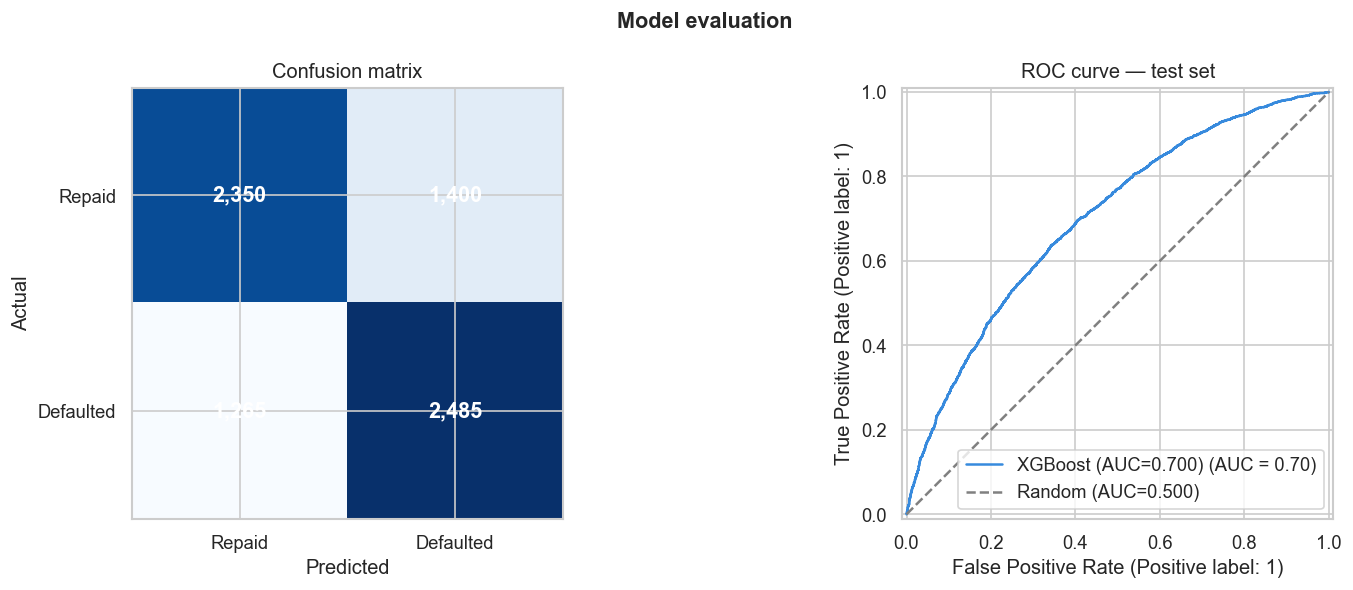

In [36]:
# Predictions
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
auc = roc_auc_score(y_test, y_prob)
print(f"Test AUC:  {auc:.4f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred,
      target_names=["Repaid", "Defaulted"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Repaid", "Defaulted"])
axes[0].set_yticklabels(["Repaid", "Defaulted"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion matrix")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm[i,j]:,}",
                     ha="center", va="center",
                     fontsize=13, fontweight="bold",
                     color="white" if cm[i,j] > cm.max()/2
                     else "black")

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    ax=axes[1],
    color="#378ADD",
    name=f"XGBoost (AUC={auc:.3f})"
)
axes[1].plot([0,1],[0,1],"--",color="gray",
             label="Random (AUC=0.500)")
axes[1].set_title("ROC curve — test set")
axes[1].legend()

plt.suptitle("Model evaluation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Computing SHAP values...


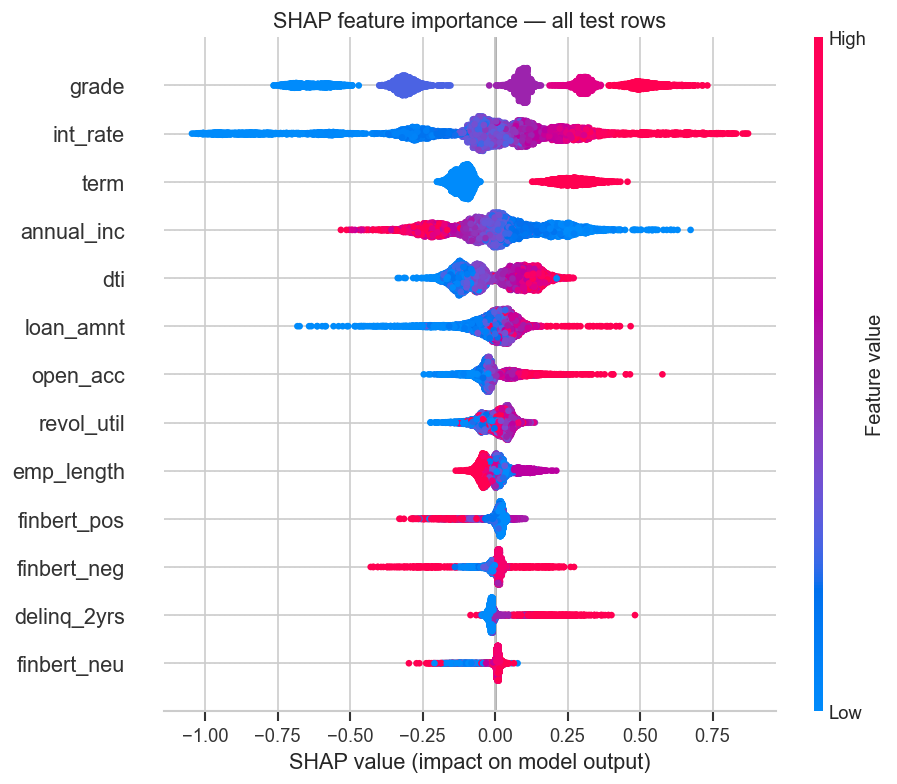

Saved: shap_summary.png

Explaining prediction for test row 4:
Actual label:     Defaulted
Predicted prob:   0.179


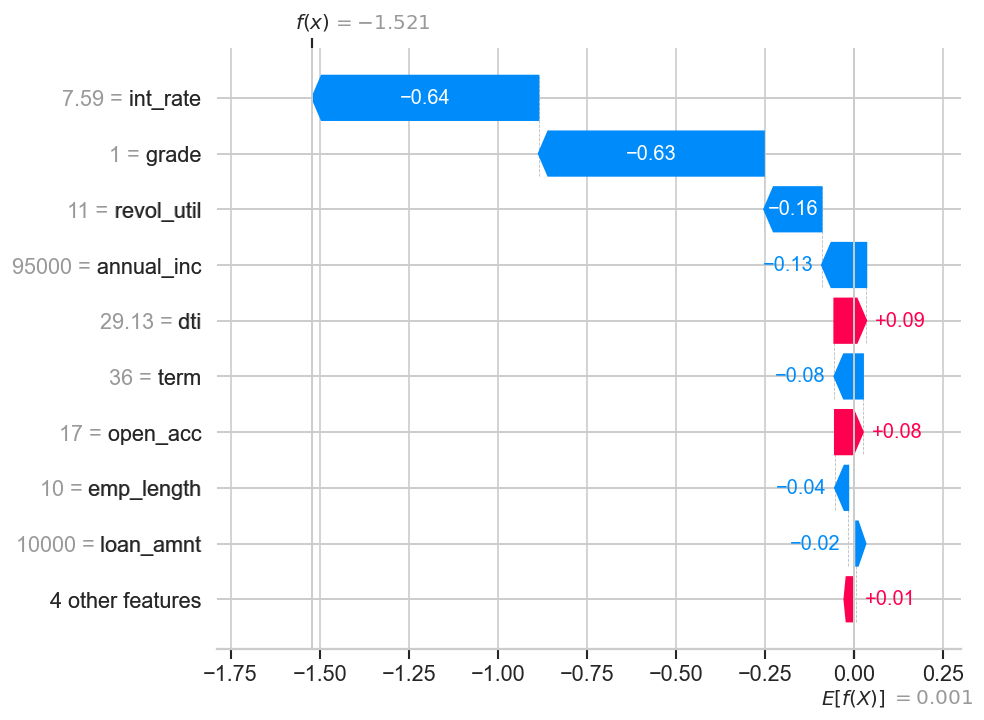

In [37]:
import shap

print("Computing SHAP values...")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURES,
    show=False
)
plt.title("SHAP feature importance — all test rows", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: shap_summary.png")

# Waterfall plot for one example prediction
# Pick one defaulted loan to explain
default_idx = np.where(y_test == 1)[0][0]
print(f"\nExplaining prediction for test row {default_idx}:")
print(f"Actual label:     {'Defaulted' if y_test[default_idx]==1 else 'Repaid'}")
print(f"Predicted prob:   {y_prob[default_idx]:.3f}")

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[default_idx],
        base_values   = explainer.expected_value,
        data          = X_test.iloc[default_idx],
        feature_names = FEATURES
    )
)

In [38]:
# Save everything needed for the FastAPI wrapper
joblib.dump(model,    "xgb_model.joblib")
joblib.dump(imputer,  "imputer.joblib")
joblib.dump(FEATURES, "features.joblib")

print("Saved:")
print("  xgb_model.joblib  — trained XGBoost model")
print("  imputer.joblib    — fitted imputer for new data")
print("  features.joblib   — feature list in correct order")
print("\nTraining complete. Ready for deployment.")

Saved:
  xgb_model.joblib  — trained XGBoost model
  imputer.joblib    — fitted imputer for new data
  features.joblib   — feature list in correct order

Training complete. Ready for deployment.


In [39]:
df = pd.read_parquet("lending_club_sample_scored.parquet")
print(df.columns.tolist())

['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'annual_inc', 'issue_d', 'desc', 'purpose', 'title', 'addr_state', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'label', 'title_clean', 'desc_clean', 'remarks', 'finbert_pos', 'finbert_neg', 'finbert_neu']
